In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import illustris_python as il

In [2]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False

plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [3]:
snapnum = 40

In [4]:
basePath = '/cosma7/data/dp004/dc-zhan5/TNG300-1'

In [5]:
fields = ['GroupFirstSub', "GroupSFR", "GroupMass", "GroupNsubs", 
          "GroupPos", "GroupMassType", "GroupBHMass", "Group_M_TopHat200", "Group_M_Crit200"]
header = il.groupcat.loadHeader(f"{basePath}/output", snapnum)
halos = il.groupcat.loadHalos(f"{basePath}/output", snapnum, fields=fields)

In [6]:
h = 0.6774

In [7]:
mvir = np.log10(halos["Group_M_TopHat200"]*1e10)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [8]:
group_sfrs = np.log10(halos["GroupSFR"])

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [9]:
fields = ["SubhaloSFR", # [Msun/yr]
          "SubhaloGrNr",
         "SubhaloFlag",
         "SubhaloPos",
         "SubhaloCM", "SubhaloHalfmassRad", "SubhaloHalfmassRadType", "SubhaloMass", "SubhaloBHMass",
         "SubhaloMassType"] # [10^10 Msun/h]
print(len(fields))
subhalos = il.groupcat.loadSubhalos(f"{basePath}/output", snapnum, fields=fields)
print(type(subhalos))

10


<class 'dict'>


In [10]:
cent_mask_all = np.full(len(subhalos["SubhaloSFR"]), False)
cent_mask_all[halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]] = True

In [11]:
cent_sfrs1 = subhalos["SubhaloSFR"][halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]]
cent_sfrs = np.zeros(len(mvir))
cent_sfrs[halos["GroupFirstSub"]>-1] = cent_sfrs1
cent_sfrs = np.log10(cent_sfrs)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:4: RuntimeWarning: divide by zero encountered in log10
  after removing the cwd from sys.path.


In [12]:
sat_sfrs = subhalos["SubhaloSFR"][~cent_mask_all]

In [13]:
sat_ids = subhalos["SubhaloGrNr"][~cent_mask_all]
unique_ids, indices = np.unique(sat_ids, return_index=True)

In [14]:
sum_sfrs1 = np.add.reduceat(sat_sfrs, indices)

In [15]:
sum_sfrs = np.zeros(len(group_sfrs))
sum_sfrs[unique_ids] = sum_sfrs1
sum_sfrs = np.log10(sum_sfrs)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:3: RuntimeWarning: divide by zero encountered in log10
  This is separate from the ipykernel package so we can avoid doing imports until


In [18]:
sat_mass = subhalos["SubhaloMass"][~cent_mask_all]
sat_mvir = mvir[subhalos["SubhaloGrNr"][~cent_mask_all]]

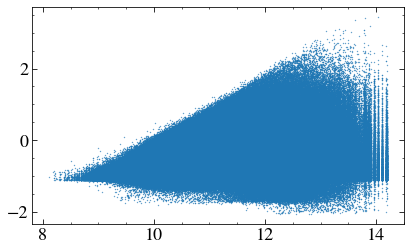

In [20]:
plt.scatter(sat_mvir, np.log10(sat_mass), s=0.1)